In [1]:
# ! pip install -U -q open-deep-research

In [95]:
# import open_deep_research  
from src import open_deep_research 
print(open_deep_research.__version__) 

0.0.10


In [96]:
from IPython.display import Image, display
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from open_deep_research.graph import builder

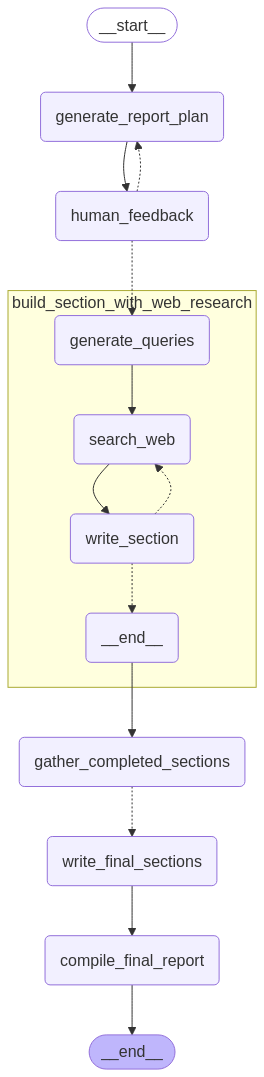

In [97]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [98]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# Set the API keys used for any model or search tool selections below, such as:
# _set_env("OPENAI_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
_set_env("TAVILY_API_KEY")
_set_env("GOOGLE_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [99]:
import uuid 
from IPython.display import Markdown

# Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "google_genai",
                           "planner_model": "gemini-2.5-pro-exp-03-25",
                           "writer_provider": "google_genai",
                           "writer_model": "gemini-2.5-pro-exp-03-25",
                           "max_search_depth": 3,
                           "number_of_queries": 5,}
                           }

# Fast config (less search depth) with o3-mini for planning and Claude 3.5 Sonnet for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "openai",
#                            "planner_model": "o3-mini",
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            "max_search_depth": 1,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# Create a topic
# topic = "Use of tranformer models and LLM encoders as vector transformers for sentiment analysis of resource poor languages such as sanskrit and punjabi"

topic = "You are tasked with analyzing a dataset containing information about customer purchases in a retail store. The dataset includes various attributes such as product categories, purchase amounts, and timestamps. Discuss how you would approach the dimensionality reduction of this dataset using PCA or autoencoders. Consider the potential benefits and limitations of each approach in capturing patterns in customer behavior, handling missing values, and interpreting the reduced representations. Additionally, propose a method for evaluating the effectiveness of dimensionality reduction techniques in preserving important information about customer purchasing behavior. Write steps for PCA and autoencoders both."

# Run the graph until the interruption
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Briefly introduce the concept of dimensionality reduction and its importance in analyzing large datasets like customer purchase history. State the report's purpose: to discuss and compare PCA and Autoencoders for this task.
Research needed: No


Section: Principal Component Analysis (PCA) for Customer Data
Description: Explain Principal Component Analysis (PCA) as a linear dimensionality reduction technique. Detail the steps for applying PCA to customer purchase data (e.g., data scaling, covariance matrix computation, eigenvector/eigenvalue decomposition, component selection). Discuss potential benefits (e.g., identifying key purchase drivers, simplifying data) and limitations (e.g., assumption of linearity, sensitivity to scaling). Address how missing values might be handled (e.g., imputation) and the interpretability of principal components.
Research needed: Yes


Section: Autoencoders for Customer Data
Description: Introduce Autoencoders as a non-linear dimensionality reduction technique using neural networks. Describe the encoder-decoder architecture. Detail the steps for applying Autoencoders (e.g., data preparation, network design, training, extracting latent representation). Discuss potential benefits (e.g., capturing complex, non-linear customer behavior patterns) and limitations (e.g., computational cost, 'black box' nature, potential for overfitting). Address handling missing values and the challenges in interpreting the reduced representations (latent space).
Research needed: Yes


Section: Comparative Analysis and Evaluation Strategy
Description: Directly compare PCA and Autoencoders based on their suitability for customer purchase data, focusing on: ability to capture linear vs. non-linear patterns, interpretability of results, computational requirements, and strategies for handling missing data. Propose methods to evaluate the effectiveness of both techniques, such as measuring reconstruction error or evaluating the performance of a downstream task (e.g., customer segmentation, purchase prediction) using the reduced dimensions.
Research needed: Yes


Section: Conclusion
Description: Provide a concise summary of the key findings. Include a structural element (e.g., a table) comparing PCA and Autoencoders across the discussed dimensions (e.g., Linearity, Interpretability, Handling Missing Values, Computational Cost, Use Case Fit, Evaluation Metric Example). Conclude with a brief statement on choosing the appropriate technique based on specific goals and data characteristics.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

In [78]:
# Pass feedback to update the report plan  
async for event in graph.astream(Command(resume="add information about whether we can input some data that was never seen by the enocder and then do its sentiment analysis somehow"), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Briefly introduce sentiment analysis, transformer models, LLMs, vector embeddings, and the challenge of applying these to low-resource languages like Sanskrit and Punjabi. State the report's purpose.
Research needed: No


Section: Transformer Encoders and Vector Embeddings
Description: Explain the architecture of transformer encoders (attention, tokenization, embeddings). Describe how encoders generate vector representations (embeddings) that capture semantic meaning, suitable for downstream tasks like sentiment analysis.
Research needed: Yes


Section: Sentiment Analysis Challenges in Low-Resource Languages
Description: Define low-resource languages and outline the specific challenges (data scarcity, lack of annotated datasets, limited tooling) for performing sentiment analysis in Sanskrit and Punjabi.
Research needed: Yes


Section: Leveraging Transformers for Low-Resource Sentiment Analysis
Description: Discuss strategies for using transformer encoders for sentiment analysis in Sanskrit and Punjabi. Cover transfer learning from high-resource or multilingual models, fine-tuning on available data, and the role of vector embeddings. Address how these models might handle previously unseen text for sentiment analysis (zero-shot/few-shot capabilities). Mention relevant tools/libraries like Hugging Face.
Research needed: Yes


Section: Conclusion
Description: Summarize the key findings. Include a table or list distilling the main points (e.g., challenges vs. solutions, model types). Reiterate the potential of transformer-based vector embeddings for sentiment analysis in low-resource languages.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

In [100]:
# Pass True to approve the report plan 
async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name='Principal Component Analysis (PCA) for Customer Data', description='Explain Principal Component Analysis (PCA) as a linear dimensionality reduction technique. Detail the steps for applying PCA to customer purchase data (e.g., data scaling, covariance matrix computation, eigenvector/eigenvalue decomposition, component selection). Discuss potential benefits (e.g., identifying key purchase drivers, simplifying data) and limitations (e.g., assumption of linearity, sensitivity to scaling). Address how missing values might be handled (e.g., imputation) and the interpretability of principal components.', research=True, content='## Principal Component Analysis (PCA) for Customer Data\n\nPrincipal Component Analysis (PCA) is a linear technique used to simplify complex, high-dimensional datasets while preserving essential patterns [2]. It transforms data into a new coordinate system where axes, c

In [101]:
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Analyzing Customer Purchase Data: Dimensionality Reduction using PCA and Autoencoders

Retail customer purchase datasets often contain a wealth of information, detailing numerous product categories, purchase amounts, frequencies, and timestamps for each customer. While rich in potential insights, the sheer volume and high dimensionality of this data present significant challenges for analysis. Extracting meaningful patterns in customer behavior, such as identifying distinct customer segments or predicting future purchases, can be computationally expensive and complex with raw, high-dimensional data. Effectively understanding customer preferences and trends requires methods to simplify this complexity without losing crucial information.

Dimensionality reduction techniques offer a powerful solution by transforming high-dimensional data into a lower-dimensional representation while preserving essential structures and patterns. Reducing the number of features can lead to more efficient processing, easier visualization, and potentially improved performance in downstream machine learning tasks like clustering or prediction. This report focuses on exploring two prominent dimensionality reduction methods applied to customer purchase history: Principal Component Analysis (PCA), a classic linear technique, and Autoencoders (AEs), a more modern non-linear approach based on neural networks. The goal is to analyze how each method can be applied to customer purchase data, discuss their respective strengths and weaknesses in capturing behavioral patterns, handling data imperfections like missing values, and interpreting the results. Furthermore, we will propose strategies for evaluating how effectively these techniques preserve the valuable information embedded within the original customer data.

## Principal Component Analysis (PCA) for Customer Data

Principal Component Analysis (PCA) is a linear technique used to simplify complex, high-dimensional datasets while preserving essential patterns [1]. It transforms data into a new coordinate system where axes, called principal components, capture the maximum variance [1]. Applying PCA to customer purchase data involves several steps.

First, the data must be standardized to ensure all features contribute equally [2, 3]. Next, the covariance matrix is computed to understand relationships between features [2, 4]. Eigendecomposition of this matrix yields eigenvalues and eigenvectors [4, 5]. Eigenvectors with the largest eigenvalues represent the principal components, capturing the most significant variance [6]. Selecting a subset of these components reduces dimensionality [7].

Benefits include simplifying data for easier exploration and identifying key purchase drivers [8, 9]. However, PCA assumes linear relationships, potentially missing non-linear patterns [10, 11]. It is also sensitive to data scaling [3, 10, 12]. Missing values typically require handling before PCA, often through imputation methods like replacing missing entries with estimations [13, 14]. Interpreting components involves examining loadings (weights of original variables) or correlations between original variables and the components [15, 16].

## Autoencoders for Customer Data

Autoencoders are unsupervised neural network models effective for non-linear dimensionality reduction [17, 18]. They feature an encoder component that compresses input data into a lower-dimensional latent representation, and a decoder component that aims to reconstruct the original data from this compressed form [19, 20]. This architecture allows autoencoders to potentially capture complex, non-linear patterns inherent in customer behavior data [17, 21].

Applying autoencoders typically involves preparing and scaling the customer data [22], designing the neural network architecture [19], and training the model to minimize reconstruction error, often using methods like stochastic gradient descent [23]. After training, the encoder part is used to transform the original high-dimensional data into the reduced latent space representation [22, 20].

A key benefit is their ability to model intricate, non-linear relationships that linear methods might miss [17, 21], aiding in feature extraction [24, 18] and potentially improving predictions of customer behavior like purchase intent [25]. However, limitations include computational cost and the "black box" nature, making the learned latent representations difficult to interpret directly [26]. While standard autoencoders cannot directly process missing data entries [27], variants and specific techniques exist to impute missing values commonly found in real-world customer datasets [28, 29].

## Comparative Analysis and Evaluation Strategy

Principal Component Analysis (PCA) and Autoencoders (AEs) offer distinct approaches for dimensionality reduction on customer purchase data. PCA, a linear technique, is effective for capturing linear relationships but struggles with complex, non-linear patterns often present in customer behavior [30, 31]. Autoencoders, using neural networks, excel at modeling these non-linear structures, potentially compressing data more efficiently when features have non-linear connections [30, 32].

While PCA yields interpretable components, AE latent representations can be less straightforward [33]. Computationally, PCA is generally efficient, suitable for large datasets, whereas AEs are more resource-intensive [33, 28]. Both methods can address missing data; frameworks exist for PCA-based imputation [34], and AEs, including masked variants designed for corrupted inputs, have shown strong imputation performance [32, 28].

Evaluating effectiveness involves measuring reconstruction error – how well original data is rebuilt from reduced dimensions [31, 35]. Assessing performance on downstream tasks like customer segmentation or purchase prediction using the reduced features is also crucial [36, 37]. Comparing this against models using original data indicates preservation of critical information [37, 38].

## Conclusion

This report analyzed Principal Component Analysis (PCA) and Autoencoders (AEs) as techniques for reducing the dimensionality of customer purchase data. The goal was to simplify the dataset while retaining meaningful patterns in customer behavior. PCA offers a linear, computationally efficient approach yielding interpretable components, effective when underlying relationships are primarily linear. Autoencoders provide a powerful, non-linear alternative capable of capturing complex patterns through their neural network architecture, but at the cost of higher computational demand and lower interpretability of the resulting latent space. Both techniques require strategies for handling missing data, either through pre-imputation or specialized model variants.

The table below summarizes the key differences discussed:

| Feature                   | Principal Component Analysis (PCA)        | Autoencoder (AE)                          |
| :------------------------ | :---------------------------------------- | :---------------------------------------- |
| **Linearity Assumption**  | Assumes linear relationships              | Can model non-linear relationships        |
| **Interpretability**      | High (via component loadings)             | Low (latent space is often a 'black box') |
| **Handling Missing Values** | Requires pre-imputation (e.g., mean)    | Requires pre-imputation or specific variants |
| **Computational Cost**    | Generally lower                           | Higher (requires training neural network) |
| **Primary Use Case Fit**  | Identifying key linear trends, data simplification | Capturing complex non-linear patterns     |
| **Evaluation Metric Example** | Reconstruction Error, Downstream Task Performance (e.g., Clustering) | Reconstruction Error, Downstream Task Performance (e.g., Clustering) |

Ultimately, the choice between PCA and Autoencoders depends on the specific analysis goals and the nature of the customer purchase data. If interpretability and efficiency are priorities for identifying major linear trends, PCA is suitable. If the primary objective is to capture potentially complex, non-linear behavioral patterns, and computational resources allow, Autoencoders offer a more flexible approach. Evaluating the chosen method based on reconstruction quality and performance impact on downstream tasks like customer segmentation or purchase prediction is crucial for ensuring valuable information is preserved.

## References

[1] Principal Component Analysis (PCA): Simplifying Data Without Losing ...: https://www.skillcamper.com/blog/principal-component-analysis-pca-simplifying-data-without-losing-insights
[2] Explain eigenvalues and eigenvectors in the context of PCA: https://datadriveninsights.io/eigenvalues-and-eigenvectors-in-pca/
[3] Dimensionality Reduction with PCA: Selecting the Largest Eigenvalues ...: https://www.geeksforgeeks.org/dimensionality-reduction-with-pca-selecting-the-largest-eigenvalues-and-eigenvectors/
[4] Principal Component Analysis: Simplifying Complex Data Sets - Statology: https://www.statology.org/principal-component-analysis-simplifying-complex-data-sets/
[5] What are Eigenvalues & Eigenvectors in PCA? (Example) - Statistics Globe: https://statisticsglobe.com/what-are-eigenvalues-eigenvectors-pca
[6] PDF: https://www.cse.psu.edu/~rtc12/CSE586Spring2010/lectures/pcaLectureShort_6pp.pdf
[7] Principal Component Analysis (PCA) - GeeksforGeeks: https://www.geeksforgeeks.org/principal-component-analysis-pca/
[8] Step-By-Step Guide to Principal Component Analysis With Example - Turing: https://www.turing.com/kb/guide-to-principal-component-analysis
[9] Principal Component Analysis Guide & Example - Statistics by Jim: https://statisticsbyjim.com/basics/principal-component-analysis/
[10] Principal Component Analysis (PCA): An In-Depth Exploration: https://medium.com/@ahmadbilalssg/principal-component-analysis-pca-an-in-depth-exploration-33838eeb8e5a
[11] Challenges and Limitations of Using PCA for Data Analysis - LinkedIn: https://www.linkedin.com/advice/0/what-some-challenges-limitations-using-principal
[12] 20 Pros And Cons Of PCA - prospluscons.com: https://prospluscons.com/pros-and-cons-of-pca/
[13] 3.7 Handling Missing Values | Principal Component Analysis for Data ...: https://pca4ds.github.io/handling-missing-values.html
[14] Data Imputation Techniques in ML - GeeksforGeeks: https://www.geeksforgeeks.org/data-imputation-techniques-in-ml/
[15] 11.4 - Interpretation of the Principal Components | STAT 505: https://online.stat.psu.edu/stat505/lesson/11/11.4
[16] PCA on sklearn - how to interpret pca.components_: https://stackoverflow.com/questions/47370795/pca-on-sklearn-how-to-interpret-pca-components
[17] Autoencoders in Deep Learning: Tutorial & Use Cases [2024] - Medium: https://www.v7labs.com/blog/autoencoders-guide
[18] What are Autoencoders? Applications and Use Cases - Analytics Vidhya: https://www.analyticsvidhya.com/blog/2023/05/unleashing-the-power-of-autoencoders-applications-and-use-cases/
[19] Introduction to Autoencoders: From The Basics to Advanced ... - DataCamp: https://www.datacamp.com/tutorial/introduction-to-autoencoders
[20] "Unlocking the Power of Autoencoders: A Practical Guide to ...: https://codezup.com/unlocking-the-power-of-autoencoders-a-practical-guide-to-dimensionality-reduction/
[21] PDF: https://cs.stanford.edu/~quocle/tutorial2.pdf
[22] Dimensional Reduction using Autoencoders - OpenGenus IQ: https://iq.opengenus.org/dimensional-reduction-using-autoencoder/
[23] Handling missing data in variational autoencoder based item response ...: https://bpspsychub.onlinelibrary.wiley.com/doi/full/10.1111/bmsp.12363
[24] Advantages and Disadvantages of Autoencoders - AspiringYouths: https://aspiringyouths.com/advantages-disadvantages/autoencoders/
[25] Generative AI for Consumer Behavior Prediction: Techniques and ... - MDPI: https://www.mdpi.com/2071-1050/16/22/9963
[26] [2106.16091] Exploring the Latent Space of Autoencoders with ...: https://arxiv.org/abs/2106.16091
[27] Filling in the Gaps: AI-Powered Data Imputation Using Autoencoders ...: https://www.xyonix.com/blog/filling-in-the-gaps-ai-powered-data-imputation-using-autoencoders
[28] Reviewing Autoencoders for Missing Data Imputation: Technical Trends ...: https://www.jair.org/index.php/jair/article/download/12312/26633
[29] Data Imputation using Autoencoders | What to do when data is missing ...: https://curiousily.com/posts/data-imputation-using-autoencoders/
[30] Autoencoders vs. PCA: Dimensionality Reduction for Complex Data: https://medium.com/@hassaanidrees7/autoencoders-vs-pca-dimensionality-reduction-for-complex-data-e07d4612b711
[31] PDF: https://orbit.dtu.dk/files/340218954/Hidden_dimensions_of_the_data_PCA_vs_autoencoders.pdf
[32] How is Autoencoder different from PCA - GeeksforGeeks: https://www.geeksforgeeks.org/how-is-autoencoder-different-from-pca/
[33] What are the key differences between Principal Component Analysis (PCA ...: https://medium.com/@sujathamudadla1213/what-are-the-key-differences-between-principal-component-analysis-pca-and-autoencoder-in-the-799582621d58
[34] Principal Components Analysis Based Frameworks for Efficient Missing ...: https://link.springer.com/chapter/10.1007/978-3-031-42430-4_21
[35] Principal Component Analysis based frameworks for efficient missing ...: https://arxiv.org/abs/2205.15150
[36] Evaluating an autoencoder: possible approaches? - Cross Validated: https://stats.stackexchange.com/questions/274123/evaluating-an-autoencoder-possible-approaches
[37] How to evaluate the autoencoder used for dimensionality reduction: https://stackoverflow.com/questions/63575817/how-to-evaluate-the-autoencoder-used-for-dimensionality-reduction
[38] A comparative dimensionality reduction study in telecom customer ...: https://journalofbigdata.springeropen.com/articles/10.1186/s40537-020-0286-0